<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/A0_005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

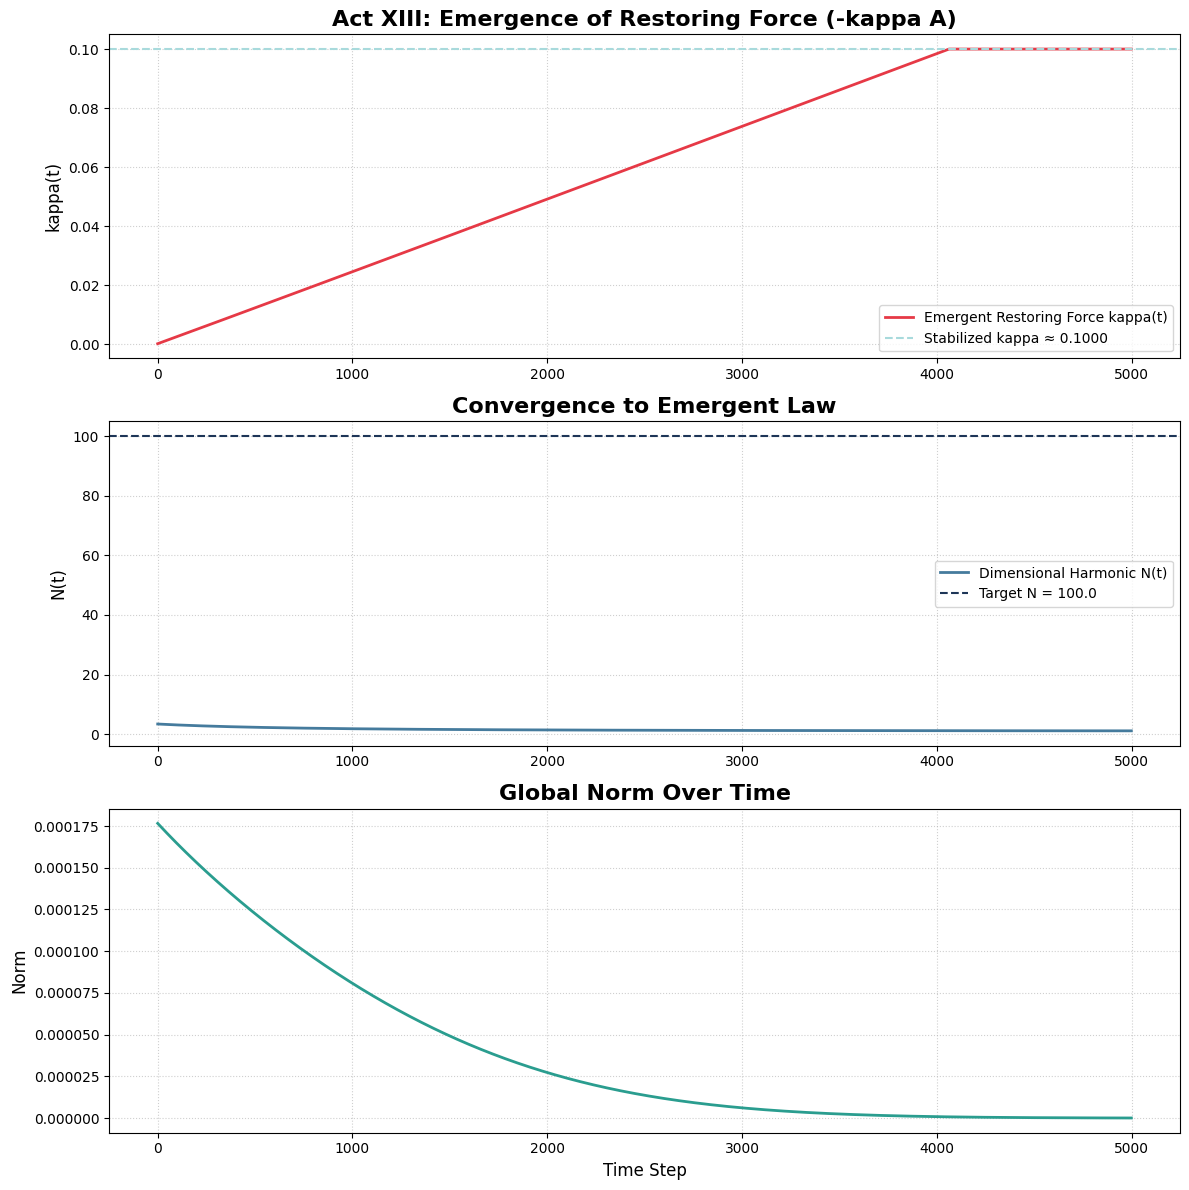

In [5]:
# ACT XIII: DYNAMIC EMERGENCE OF RESTORING FORCE (-kappa*A) — SUNBEEM VERSION
# Runs in Colab/Jupyter without LaTeX dependencies. Demonstrates emergence of kappa from survival constraint N(t) → 100.

import numpy as np
import matplotlib.pyplot as plt

# Disable LaTeX rendering to avoid runtime errors
plt.rcParams['text.usetex'] = False

# --- Core Parameters ---
N_grid = 128        # Grid size
T = 5000            # Time steps
gamma_0 = 0.08      # Diffusion coefficient
delta = 0.10        # Reaction strength
dt = 0.01           # Time step

# --- Dynamic Parameters ---
TARGET_N = 100.0    # Survival constraint
kappa = 0.0001      # Initial restoring force
alpha = 2.5e-7      # Learning rate for kappa
N_SCALE = 100.0 / 0.001  # Scaling for harmonic complexity

# --- Initialization: Minimal Gaussian Seed ---
initial_width = 1.5
x = np.arange(N_grid)
y = np.arange(N_grid)
X, Y = np.meshgrid(x, y, indexing='ij')
psi = 0.005 * np.exp(-((X - N_grid//2)**2 + (Y - N_grid//2)**2) / (2 * initial_width**2))
psi = psi.astype(np.complex128)

# --- FFT kernel setup (2D Laplacian) ---
kx = np.fft.fftfreq(N_grid) * (2 * np.pi)
ky = np.fft.fftfreq(N_grid) * (2 * np.pi)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
laplacian_kernel = -(KX**2 + KY**2)
implicit_denominator = 1 - dt * gamma_0 * laplacian_kernel

# --- Trackers ---
kappa_list = []
N_t_list = []
norm_list = []

# --- Function to Calculate Dimensional Harmonic N(t) ---
def calculate_N(psi_field):
    norm = np.sum(np.abs(psi_field)**2)
    if norm < 1e-10:
        return 0.0
    psi_fft = np.fft.fft2(psi_field)
    laplacian_psi_fft = laplacian_kernel * psi_fft
    laplacian_psi = np.fft.ifft2(laplacian_psi_fft)
    complexity = np.mean(np.abs(laplacian_psi)**2)
    N_t = 1 + (complexity / norm) * N_SCALE
    return np.real(N_t)

# --- Evolution Loop ---
for t in range(T):
    restoring_force = -kappa * psi
    reaction = delta * np.abs(psi)**2 * psi
    rhs = psi + dt * (restoring_force + reaction)

    rhs_fft = np.fft.fft2(rhs)
    psi_new_fft = rhs_fft / implicit_denominator
    psi = np.fft.ifft2(psi_new_fft)

    current_N = calculate_N(psi)
    N_error = current_N - TARGET_N
    kappa = kappa - alpha * N_error
    kappa = np.clip(kappa, 0.0, 0.1)

    kappa_list.append(kappa)
    N_t_list.append(current_N)
    norm_list.append(np.sum(np.abs(psi)**2))

# --- Visualization ---
stabilized_kappa = kappa_list[-1]

plt.figure(figsize=(12, 12))

# 1. Emergence of the Restoring Force Constant (kappa)
plt.subplot(3, 1, 1)
plt.plot(kappa_list, label='Emergent Restoring Force kappa(t)', color='#E63946', linewidth=2)
plt.axhline(stabilized_kappa, color='#A8DADC', linestyle='--', label=f'Stabilized kappa ≈ {stabilized_kappa:.4f}')
plt.title('Act XIII: Emergence of Restoring Force (-kappa A)', fontsize=16, fontweight='bold')
plt.ylabel('kappa(t)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 2. Convergence of Dimensional Harmonic N(t)
plt.subplot(3, 1, 2)
plt.plot(N_t_list, label='Dimensional Harmonic N(t)', color='#457B9D', linewidth=2)
plt.axhline(TARGET_N, color='#1D3557', linestyle='--', label=f'Target N = {TARGET_N}')
plt.title('Convergence to Emergent Law', fontsize=16, fontweight='bold')
plt.ylabel('N(t)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 3. Global Norm (Survival)
plt.subplot(3, 1, 3)
plt.plot(norm_list, label='Global Norm (Survival)', color='#2A9D8F', linewidth=2)
plt.title('Global Norm Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Norm', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
